In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/hotel_bookings_transformed.csv")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city,lead_time_group,special_requests_group
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2024-07-27 22:16:40.916332324,Chandigarh,181-365 dni,0
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2024-04-28 21:56:21.507509066,Mumbai,365+ dni,0
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2024-09-10 03:46:25.734029096,Delhi,0-7 dni,0
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2024-08-14 18:07:10.049669568,Kolkata,8-30 dni,0
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,0,Transient,98.0,0,1,Check-Out,2024-09-14 14:27:32.473846000,Lucknow,8-30 dni,1


In [4]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [5]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} wartości")

hotel: 30 wartości
arrival_date_month: 12 wartości
meal: 5 wartości
country: 177 wartości
market_segment: 7 wartości
distribution_channel: 5 wartości
reserved_room_type: 10 wartości
assigned_room_type: 12 wartości
deposit_type: 3 wartości
customer_type: 4 wartości
reservation_status: 3 wartości
reservation_status_date: 75441 wartości
city: 15 wartości
lead_time_group: 6 wartości
special_requests_group: 5 wartości


/var/folders/jk/s6499gz530v3223pyhj2616m0000gn/T/ipykernel_77684/3673398717.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [6]:
df_model = df.drop(
    columns=["reservation_status", "reservation_status_date"]
)

df_model.shape

(118898, 32)

In [7]:
df_model.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'city',
 'lead_time_group',
 'special_requests_group']

In [8]:
X = df_model.drop(
    columns=["is_canceled", "lead_time_group", "special_requests_group"]
)

y = df_model["is_canceled"]

print("X:", X.shape)
print("y:", y.shape)

X: (118898, 29)
y: (118898,)


In [9]:
X.select_dtypes(include="object").columns.tolist()


/var/folders/jk/s6499gz530v3223pyhj2616m0000gn/T/ipykernel_77684/2367273465.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns.tolist()


['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'city']

In [10]:
for col in X.select_dtypes(include="object").columns:
    print(f"{col}: {X[col].nunique()} kategorii")

hotel: 30 kategorii
arrival_date_month: 12 kategorii
meal: 5 kategorii
country: 177 kategorii
market_segment: 7 kategorii
distribution_channel: 5 kategorii
reserved_room_type: 10 kategorii
assigned_room_type: 12 kategorii
deposit_type: 3 kategorii
customer_type: 4 kategorii
city: 15 kategorii


/var/folders/jk/s6499gz530v3223pyhj2616m0000gn/T/ipykernel_77684/440942550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object").columns:


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (95118, 29)
X_test: (23780, 29)
y_train: (95118,)
y_test: (23780,)


In [12]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numeric_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Kolumny kategoryczne:")
print(categorical_cols)

print("\nKolumny numeryczne:")
print(numeric_cols)

Kolumny kategoryczne:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'city']

Kolumny numeryczne:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


/var/folders/jk/s6499gz530v3223pyhj2616m0000gn/T/ipykernel_77684/1659666122.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


Przygotowanie danych do modelowania – preprocessing


In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)

In [16]:
X_train_processed.shape

(95118, 289)

In [17]:
X_test_processed = preprocessor.transform(X_test)
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

X_train_processed: (95118, 289)
X_test_processed: (23780, 289)


In [18]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [19]:
y_pred = model.predict(X_test_processed)

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8182926829268292


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86     14949
           1       0.82      0.66      0.73      8831

    accuracy                           0.82     23780
   macro avg       0.82      0.79      0.80     23780
weighted avg       0.82      0.82      0.81     23780



In [22]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[13665  1284]
 [ 3037  5794]]


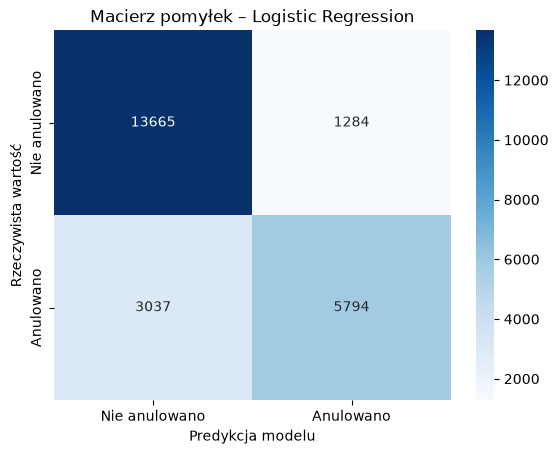

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Nie anulowano", "Anulowano"],
    yticklabels=["Nie anulowano", "Anulowano"]
)

plt.xlabel("Predykcja modelu")
plt.ylabel("Rzeczywista wartość")
plt.title("Macierz pomyłek – Logistic Regression")
plt.show()

In [24]:
train_accuracy = model.score(X_train_processed, y_train)
test_accuracy = model.score(X_test_processed, y_test)

print("Accuracy train:", train_accuracy)
print("Accuracy test:", test_accuracy)

Accuracy train: 0.8152610441767069
Accuracy test: 0.8182926829268292


In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [27]:
rf_pred = rf_model.predict(X_test_processed)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8721194280908326


In [28]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90     14949
           1       0.88      0.76      0.82      8831

    accuracy                           0.87     23780
   macro avg       0.87      0.85      0.86     23780
weighted avg       0.87      0.87      0.87     23780



In [29]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[14026   923]
 [ 2118  6713]]


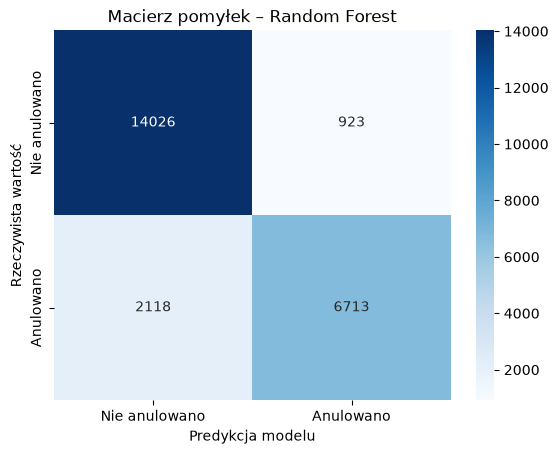

In [30]:
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Nie anulowano", "Anulowano"],
    yticklabels=["Nie anulowano", "Anulowano"]
)

plt.xlabel("Predykcja modelu")
plt.ylabel("Rzeczywista wartość")
plt.title("Macierz pomyłek – Random Forest")
plt.show()

In [31]:
rf_train_accuracy = rf_model.score(X_train_processed, y_train)
rf_test_accuracy = rf_model.score(X_test_processed, y_test)

print("Random Forest Accuracy train:", rf_train_accuracy)
print("Random Forest Accuracy test:", rf_test_accuracy)

Random Forest Accuracy train: 1.0
Random Forest Accuracy test: 0.8721194280908326


In [32]:
rf_model_2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model_2.fit(X_train_processed, y_train)

rf_pred_2 = rf_model_2.predict(X_test_processed)

rf_accuracy_2 = accuracy_score(y_test, rf_pred_2)

print("Random Forest (max_depth=15) Accuracy:", rf_accuracy_2)

Random Forest (max_depth=15) Accuracy: 0.8405382674516401


In [33]:
rf_train_accuracy_2 = rf_model_2.score(X_train_processed, y_train)
rf_test_accuracy_2 = rf_model_2.score(X_test_processed, y_test)

print("Random Forest (max_depth=15) train:", rf_train_accuracy_2)
print("Random Forest (max_depth=15) test:", rf_test_accuracy_2)

Random Forest (max_depth=15) train: 0.851710506949263
Random Forest (max_depth=15) test: 0.8405382674516401


In [34]:
print(classification_report(y_test, rf_pred_2))

              precision    recall  f1-score   support

           0       0.82      0.96      0.88     14949
           1       0.91      0.63      0.75      8831

    accuracy                           0.84     23780
   macro avg       0.86      0.80      0.81     23780
weighted avg       0.85      0.84      0.83     23780



In [35]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest (max_depth=15)"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        rf_accuracy_2
    ],
    "Train Accuracy": [
        train_accuracy,
        rf_train_accuracy,
        rf_train_accuracy_2
    ]
})

comparison

,Model,Accuracy,Train Accuracy
0,Logistic Regression,0.818293,0.815261
1,Random Forest,0.872119,1.000000
2,Random Forest (max_depth=15),0.840538,0.851711


In [36]:
feature_importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,num__lead_time,0.091089
267,cat__deposit_type_No Deposit,0.065996
193,cat__country_PRT,0.058090
15,num__adr,0.057660
268,cat__deposit_type_Non Refund,0.053224
17,num__total_of_special_requests,0.047976
13,num__agent,0.040799
3,num__arrival_date_day_of_month,0.037483
2,num__arrival_date_week_number,0.035079
5,num__stays_in_week_nights,0.029073


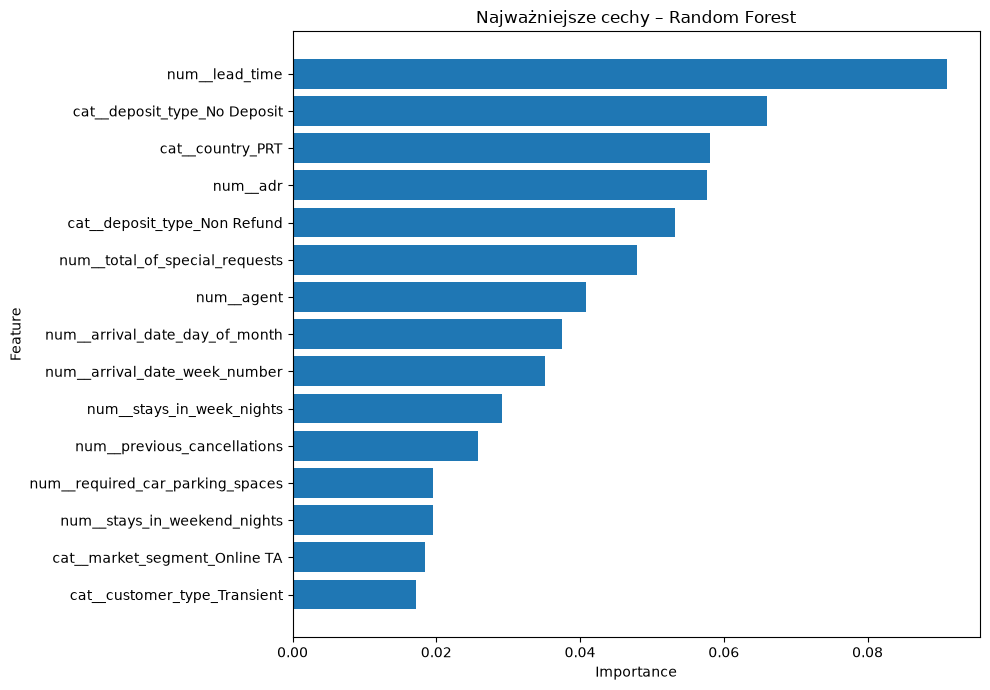

In [37]:
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Najważniejsze cechy – Random Forest")
plt.tight_layout()
plt.show()

In [38]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest (max_depth=15)"
    ],
    "Train Accuracy": [
        train_accuracy,
        rf_train_accuracy,
        rf_train_accuracy_2
    ],
    "Test Accuracy": [
        test_accuracy,
        rf_test_accuracy,
        rf_test_accuracy_2
    ]
})

final_results

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.815261,0.818293
1,Random Forest,1.000000,0.872119
2,Random Forest (max_depth=15),0.851711,0.840538


Najlepszą skuteczność uzyskał model Random Forest bez ograniczenia głębokości - accuracy 87,2% na zbiorze testowym. Jednocześnie różnica pomiędzy skutecznością na zbiorze train (100%) i test (87,2%) wskazuje na występowanie overfitting. Ograniczenie głębokości drzew do 15 zmniejszyło różnicę między wynikami treningowymi i testowymi, ale obniżyło skuteczność modelu do 84,1%

## Regresja liniowa – przewidywanie ADR


In [39]:
# Target dla regresji liniowej
y_reg = df["adr"]

# Zmienne wejściowe
X_reg = df.drop(columns=["adr"])

In [40]:
print("X_reg:", X_reg.shape)
print("y_reg:", y_reg.shape)

X_reg: (118898, 33)
y_reg: (118898,)


In [41]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [42]:
print("X_reg_train:", X_reg_train.shape)
print("X_reg_test:", X_reg_test.shape)
print("y_reg_train:", y_reg_train.shape)
print("y_reg_test:", y_reg_test.shape)

X_reg_train: (95118, 33)
X_reg_test: (23780, 33)
y_reg_train: (95118,)
y_reg_test: (23780,)


In [43]:
categorical_cols_reg = X_reg_train.select_dtypes(include="object").columns.tolist()
numeric_cols_reg = X_reg_train.select_dtypes(exclude="object").columns.tolist()

print("Kolumny kategoryczne:", len(categorical_cols_reg))
print("Kolumny numeryczne:", len(numeric_cols_reg))

Kolumny kategoryczne: 15
Kolumny numeryczne: 18


/var/folders/jk/s6499gz530v3223pyhj2616m0000gn/T/ipykernel_77684/1394322060.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_reg = X_reg_train.select_dtypes(include="object").columns.tolist()


In [44]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols_reg),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_reg)
    ]
)

In [45]:
X_reg_train_processed = preprocessor_reg.fit_transform(X_reg_train)
X_reg_test_processed = preprocessor_reg.transform(X_reg_test)

LinearRegression()

In [46]:
model_reg = LinearRegression()

model_reg.fit(X_reg_train_processed, y_reg_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](66051,)","[-0.05,-3.64, 0. ,...,-0.79,-6.01,-8.25]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,111.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,66051


### Predykcja

In [47]:
y_reg_pred = model_reg.predict(X_reg_test_processed)

In [48]:
print("Liczba predykcji:", len(y_reg_pred))

Liczba predykcji: 23780


### Ocena modelu

In [49]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_reg_test, y_reg_pred)
rmse = mean_squared_error(y_reg_test, y_reg_pred) ** 0.5

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.15108794882787835
RMSE: 43.841435236832666


In [50]:
porownanie = pd.DataFrame({
    "Rzeczywiste ADR": y_reg_test.values[:10],
    "Przewidywane ADR": y_reg_pred[:10]
})

porownanie

,Rzeczywiste ADR,Przewidywane ADR
0,91.00,124.743655
1,140.00,101.679715
2,122.40,82.209536
3,77.50,140.702816
4,89.00,78.519208
5,88.68,154.847770
6,168.30,152.014158
7,71.00,105.384162
8,113.00,126.311309
9,74.80,103.780742


### Wnioski

Model regresji liniowej osiągnął R² na poziomie 0,151 oraz RMSE wynoszące 43,84. Oznacza to, że model wyjaśnia około 15,1% zmienności wartości ADR, a jego predykcje różnią się od wartości rzeczywistych średnio o około 43,84 jednostki ADR. Wynik wskazuje na ograniczoną skuteczność regresji liniowej w przewidywaniu ceny pokoju na podstawie wykorzystanych zmiennych.